# Oscar — early-warning model: predictors from 3 months in

28 Sep 2026. Rough working.

**Why a new notebook.** Alex reviewed notebooks `01`–`04`
([`Alex/01-review-and-next-steps.md`](../Alex/01-review-and-next-steps.md)),
and we talked it through. We agreed to reframe the question and the method a
little, so this notebook starts again from the cleaned data rather than
patching `03-predictors` and `04-logistic`.

**What changed:**

* **The question.** `03` and `04` used all six months, and September's status
  (`PAY_0` there, `PAY_1` in the cleaned data) dominated. But a customer already behind in September has, in
  effect, already defaulted. A model that leans on `PAY_1` answers an easy
  question too late to act on. The new question:
  > Using only the **first 3 months** of behaviour (Apr–Jun 2005) plus the
  > customer's details, predict whether they default in October 2005.
* **The baseline to beat.** Alex's check of plain logistic regression on this
  scope scored AUC 0.652, Brier score 0.160 (0.172 for predicting 22% for
  everyone). It caught only 101 of 1,658 defaulters at the 0.5 threshold.
  With all six months it scored AUC 0.72, so this question is noticeably harder.
* **Method.** Treat `PAY_*` and the category columns as categories, not
  numbers. Deal with the overlapping bill columns, e.g. with summaries such as
  utilisation (bill / limit). Score with Brier skill + AUC, and choose any
  threshold on validation data, never on the test set.

This notebook covers step 1: which columns carry signal **within the new scope**.
Modelling and scoring come later.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

ROOT = Path.cwd().parent
taiwan = pd.read_csv(ROOT / "data" / "processed" / "taiwan-clean.csv", index_col="ID")
Y = "default payment next month"
taiwan.shape

(29995, 24)

## The scope: which columns are allowed

The months run backwards in the column names (`1` = September):

| Month | Apr | May | Jun | Jul | Aug | Sep | **Oct** |
|---|---|---|---|---|---|---|---|
| Status | `PAY_6` | `PAY_5` | `PAY_4` | `PAY_3` | `PAY_2` | `PAY_1` | **default?** |
| Bill / paid | `*_AMT6` | `*_AMT5` | `*_AMT4` | `*_AMT3` | `*_AMT2` | `*_AMT1` | |

So we keep the **Jun, May, Apr** columns (numbers 4, 5, 6) and the customer
columns that don't change over time. Everything from July onwards is dropped.

This uses `data/processed/taiwan-clean.csv` from `05-cleaning`. It has 29,995
rows, which isn't quite the same as Alex's 29,965 (he dropped every exact
duplicate). His numbers are a guide, not an exact target.

In [2]:
STATIC = ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE"]
MONTHS = [4, 5, 6]                                   # Jun, May, Apr
STATUS = [f"PAY_{m}" for m in MONTHS]
BILL   = [f"BILL_AMT{m}" for m in MONTHS]
PAID   = [f"PAY_AMT{m}" for m in MONTHS]
IN_SCOPE = STATIC + STATUS + BILL + PAID

X = taiwan[IN_SCOPE]
y = taiwan[Y]
print(len(IN_SCOPE), "columns in scope; dropped:",
      [c for c in taiwan.columns if c not in IN_SCOPE + [Y]])

14 columns in scope; dropped: ['PAY_1', 'PAY_2', 'PAY_3', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3']


## Step 1 — each in-scope column on its own: mutual information

The same measure as `03-predictors`: how much knowing a column reduces the
uncertainty about default, in nats (0 = tells you nothing). This time only the
in-scope columns are included, so we can see what's left once `PAY_1`–`PAY_3`
are gone.

The categorical columns (`SEX`, `EDUCATION`, `MARRIAGE`, `PAY_*`) are marked
**discrete**, so MI treats each code as its own group. For the money columns and
`AGE`, MI is estimated from nearest neighbours, which is random, so
`random_state=0` makes it repeatable. `AGE` came out at 0 that way in `03`,
though its default rate is U-shaped, so we also report it treated as discrete.

In [3]:
DISCRETE = ["SEX", "EDUCATION", "MARRIAGE"] + STATUS

mi = mutual_info_classif(X, y, discrete_features=X.columns.isin(DISCRETE), random_state=0)
mi = pd.Series(mi, index=X.columns)
mi["AGE (as discrete)"] = mutual_info_classif(X[["AGE"]], y, discrete_features=True)[0]

p = y.mean()
label_entropy = -(p * np.log(p) + (1 - p) * np.log(1 - p))
print(f"default rate {p:.3f}; label entropy {label_entropy:.3f} nats")

pd.DataFrame({"MI (nats)": mi, "% of label entropy": 100 * mi / label_entropy}
             ).sort_values("MI (nats)", ascending=False).round(4)

default rate 0.221; label entropy 0.528 nats


,MI (nats),% of label entropy
PAY_4,0.0328,6.2159
PAY_5,0.0305,5.7729
PAY_6,0.0264,4.9928
PAY_AMT4,0.0140,2.6553
PAY_AMT5,0.0139,2.6375
PAY_AMT6,0.0131,2.4850
LIMIT_BAL,0.0116,2.1908
BILL_AMT5,0.0058,1.0958
BILL_AMT6,0.0051,0.9647
BILL_AMT4,0.0040,0.7657


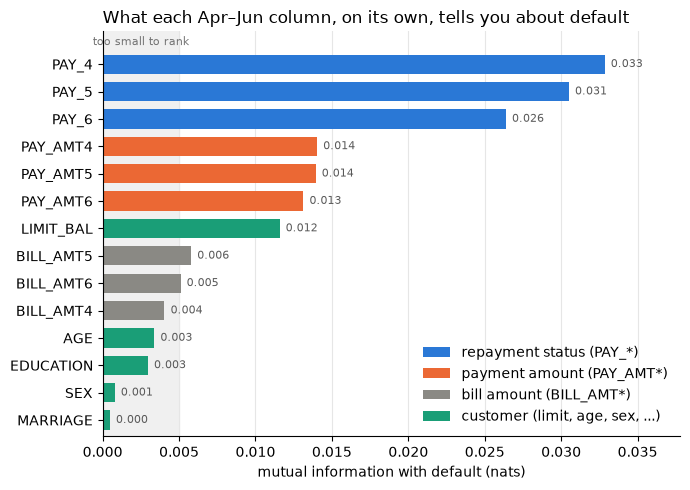

In [4]:
import matplotlib.pyplot as plt

# Same colours and layout as the MI plot in 03-predictors, so the two can be
# compared side by side. "AGE (as discrete)" is only a cross-check, so it stays
# in the table above but is left off the plot.
GROUP_COLOURS = {"repayment status (PAY_*)": "#2a78d6",
                 "payment amount (PAY_AMT*)": "#eb6834",
                 "bill amount (BILL_AMT*)": "#8a8984",
                 "customer (limit, age, sex, ...)": "#1a9e77"}

def group(col):
    if col.startswith("PAY_AMT"): return "payment amount (PAY_AMT*)"
    if col.startswith("PAY_"):    return "repayment status (PAY_*)"
    if col.startswith("BILL"):    return "bill amount (BILL_AMT*)"
    return "customer (limit, age, sex, ...)"

order = mi[IN_SCOPE].sort_values()          # barh draws from the bottom up
fig, ax = plt.subplots(figsize=(7, 5))

# Shade values this small: the notes treat gaps under ~0.005 as noise, so these
# columns are "about zero" and their order among themselves means little.
ax.axvspan(0, 0.005, color="0.94", zorder=0)
ax.text(0.0025, len(order) - 0.4, "too small to rank", ha="center", va="bottom",
        fontsize=8, color="0.45")

ax.barh(order.index, order.values, height=0.7,
        color=[GROUP_COLOURS[group(c)] for c in order.index])
for yi, v in enumerate(order.values):       # value at the end of each bar
    ax.text(v + 0.0004, yi, f"{v:.3f}", va="center", fontsize=8, color="0.35")
for name, colour in GROUP_COLOURS.items():  # legend entries
    ax.barh(0, 0, color=colour, label=name)
ax.legend(frameon=False, loc="lower right")

ax.set_xlim(0, order.max() * 1.15)
ax.set_ylim(-0.6, len(order) + 0.2)
ax.set_xlabel("mutual information with default (nats)")
ax.set_title("What each Apr–Jun column, on its own, tells you about default", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="0.9"); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Notes so far (rough)

* **Repayment status still leads**, even without the last three months:
  `PAY_4` (June) 0.033 nats, then May and April. But the top in-scope column
  carries under half of what September's status (`PAY_0`) did in `03` (0.076). That fits the drop
  in AUC from 0.72 to about 0.65.
* **Payments made come next** (`PAY_AMT4`–`6`, about 0.013-0.014 each), then
  `LIMIT_BAL`. Bills are weaker. Demographics are still close to nothing.
* **The continuous MI values move around.** Compared with `03`, `LIMIT_BAL` fell
  from 0.018 to 0.012 and `PAY_AMT4` from 0.018 to 0.014. `AGE` rose from 0 to
  0.003. The data (clean file, 5 fewer rows) and the nearest-neighbour estimate
  both changed, so treat differences under about 0.005 as noise, not a ranking.
* **Next:** do the in-scope columns overlap (VIF on the bills), and do summary
  columns (worst status over Apr-Jun, months late, utilisation = bill / limit,
  payment / bill) carry more than the raw columns they replace?